## Симулируем распространение болезни в сети аэропортов

### Окружение

Датасет: [US Flights Data 2008](https://www.kaggle.com/datasets/vikalpdongre/us-flights-data-2008) — все внутренние рейсы США за 2008 год по данным Министерства транспорта. Задача: смоделировать распространение инфекции по сети аэропортов SI-моделью и понять, помогает ли структура сети предсказать, кто заразится раньше.

В SI-модели аэропорт бывает только здоровым или заражённым, вылечиться нельзя. Прилетел самолёт из заражённого города — здоровый аэропорт заражается с вероятностью `p`.

In [1]:
%pip install -q numpy pandas networkx scipy matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Загрузка данных

Kaggle отдаёт файлы только по токену. Берём зеркало Harvard Dataverse — тот же файл ASA Data Expo 2009, из которого собран датасет на Kaggle.

Второй файл — база аэропортов OpenFlights, из неё берутся часовые пояса.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

SOURCES = {
    "2008.csv.bz2": "https://dataverse.harvard.edu/api/access/datafile/1374917",
    "airports.dat": "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat",
}

# Путь относительный: рабочая директория ядра — папка с ноутбуком.
for name, url in SOURCES.items():
    path = Path("data") / name
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        urlretrieve(url, path)
    print(f"{str(path):20} {path.stat().st_size / 1024 ** 2:6.1f} МБ")

data/2008.csv.bz2      37.5 МБ
data/airports.dat       1.1 МБ


## EDA

### Первичный осмотр

In [3]:
import pandas as pd

# Из 29 колонок нужны только эти: откуда, куда, когда и сколько летел.
COLS = ["Month", "DayofMonth", "DepTime", "ActualElapsedTime",
        "Origin", "Dest", "Cancelled", "Diverted"]

df = pd.read_csv("data/2008.csv.bz2", usecols=COLS)
df.head()

,Month,DayofMonth,DepTime,ActualElapsedTime,Origin,Dest,Cancelled,Diverted
0,1,3,1343.0,68.0,HOU,LIT,0,0
1,1,3,1125.0,82.0,HOU,MAF,0,0
2,1,3,2009.0,87.0,HOU,MAF,0,0
3,1,3,903.0,120.0,HOU,MCO,0,0
4,1,3,1423.0,123.0,HOU,MCO,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2389217 entries, 0 to 2389216
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Month              int64  
 1   DayofMonth         int64  
 2   DepTime            float64
 3   ActualElapsedTime  float64
 4   Origin             str    
 5   Dest               str    
 6   Cancelled          int64  
 7   Diverted           int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 145.8 MB


Время в датасете местное и записано числом `hhmm`: `1343` — это 13:43. Дата разложена по колонкам `Month` и `DayofMonth`.

`ActualElapsedTime` — фактическая длительность рейса в минутах, из неё считается время прилёта.

### Шаг 1. Какой месяц берём

Смотрим, какие месяцы есть в файле и все ли они полные.

In [5]:
by_month = df.Month.value_counts().sort_index()
days = df.groupby("Month").DayofMonth.nunique()

print(pd.DataFrame({"рейсов": by_month, "суток": days}).to_string())
print()
print(f"всего рейсов: {len(df):,}".replace(",", " "))

       рейсов  суток
Month               
1      605765     31
2      569236     29
3      616090     31
4      598126     30

всего рейсов: 2 389 217


В зеркале только первые четыре месяца 2008 года. Зато каждый из них целый: 31, 29, 31 и 30 суток, рейсов в сутки везде около 20 тысяч.

Берём **январь**. Он полный, и вся страна в январе живёт по зимнему времени. Значит, смещение до GMT у каждого аэропорта одно на весь месяц.

### Шаг 2. Отменённые рейсы и уходы на запасной

`Cancelled` — рейс не состоялся. `Diverted` — самолёт вылетел, но сел не в запланированном аэропорту: погода, закрытая полоса, нештатная ситуация на борту.

In [6]:
jan = df[df.Month == 1]
div = jan.Diverted == 1

print(f"рейсов в январе        : {len(jan):,}".replace(",", " "))
print(f"  отменено             : {jan.Cancelled.sum():,}".replace(",", " "))
print(f"  ушло на запасной     : {jan.Diverted.sum():,}".replace(",", " "))
print(f"    без длительности   : {jan.loc[div, 'ActualElapsedTime'].isna().sum():,}".replace(",", " "))
print(f"  нет времени вылета   : {jan.DepTime.isna().sum():,}".replace(",", " "))

jan = jan[(jan.Cancelled == 0) & (jan.Diverted == 0)].copy()

print()
print(f"осталось               : {len(jan):,}".replace(",", " "))
print(f"пропусков в остатке    : {int(jan[['DepTime', 'ActualElapsedTime']].isna().sum().sum())}")

рейсов в январе        : 605 765
  отменено             : 17 308
  ушло на запасной     : 1 327
    без длительности   : 1 327
  нет времени вылета   : 17 308

осталось               : 587 130
пропусков в остатке    : 0


Отменённые убираем: без вылета нет и контакта. Времени вылета нет как раз у них.

Ушедшие на запасной инфекцию переносят, но в аэропорт, которого в строке нет: `Dest` указывает на запланированный, куда борт как раз не прилетел, а фактический не записан. Под него есть поля `Div1Airport`…`Div5Airport`, но за январь 2008 они пустые. По той же причине пусты `ArrTime` и `ActualElapsedTime`. Убираем и их. Оставить с записанным `Dest` значило бы 1327 раз заразить аэропорт, в котором борта не было; выбросить — потерять 0,22% рейсов.

Осталось 587 130 записей

### Шаг 3. Сколько аэропортов и кто из них главный

In [7]:
airports_used = sorted(set(jan.Origin) | set(jan.Dest))
traffic = pd.concat([jan.Origin, jan.Dest]).value_counts()

print(f"аэропортов: {len(airports_used)}")
print()
print("топ-5 по числу рейсов:")
print(traffic.head().to_string())
print()
print(f"ABE (Allentown): рейсов {traffic.get('ABE', 0)}, место {list(traffic.index).index('ABE') + 1} из {len(traffic)}")

аэропортов: 286

топ-5 по числу рейсов:
ATL    65170
ORD    54945
DFW    46295
DEN    38155
LAX    36991

ABE (Allentown): рейсов 774, место 142 из 286


Стартовый аэропорт в задании задан как `node_id = 0`. Такой нумерации в данных нет, поэтому берём Allentown по коду IATA — **ABE**. Он на месте: 774 рейса за месяц и 142-е место по трафику из 286.

### Шаг 4. Местное время и часовые пояса

`DepTime` — местное время. Если сравнивать местные времена напрямую порядок событий сломается.

Смещения до GMT берём из OpenFlights.

In [8]:
OF_COLS = ["of_id", "name", "city", "country", "iata", "icao", "lat", "lon",
           "alt", "tz_hours", "dst", "tz_name", "type", "source"]

air = pd.read_csv("data/airports.dat", names=OF_COLS, header=None, na_values=[r"\N"])
air = air[air.iata.notna() & (air.iata.str.len() == 3)].drop_duplicates("iata")
offset = air.set_index("iata")["tz_hours"]

missing = [a for a in airports_used if a not in offset.index]

print(f"аэропортов без смещения: {len(missing)} {missing}")
print()
print("сколько аэропортов в каком поясе:")
print(offset.reindex(airports_used).value_counts().sort_index().to_string())
print()
print(air.loc[air.iata == "ABE", ["iata", "name", "city", "tz_hours"]].to_string(index=False))

аэропортов без смещения: 0 []

сколько аэропортов в каком поясе:
tz_hours
-10.0     6
-9.0     15
-8.0     41
-7.0     36
-6.0     87
-5.0     96
-4.0      5

iata                                name      city  tz_hours
 ABE Lehigh Valley International Airport Allentown      -5.0


Покрытие полное — ни одного аэропорта без смещения. Поясов семь: от −4 до −10.

Allentown в поясе −5.

### Найденные несостыковки

1. **Зеркало датасета неполное** — январь—апрель вместо всего 2008 года. Каждый из четырёх месяцев при этом целый, так что на выбор месяца это не влияет.
2. **`node_id` из задания в данных нет.** Стартовый аэропорт задаём кодом IATA `ABE`.
3. **Время местное, а не GMT.** Без перевода порядок вылетов между поясами получается неверным.
4. **Файл не отсортирован по времени.** Задание предлагает пройти по датасету через `itertuples`, но сперва нужна сортировка по времени вылета.

## Предобработка

### Шаг 1. Таблица событий

Приводим данные к формату эталонного датасета: `Source`, `Destination`, `StartTime`, `EndTime` — время в секундах GMT.

In [9]:
import numpy as np

# DepTime = 2400 означает полночь следующих суток.
dep = jan.DepTime.astype(int)
next_day = (dep == 2400).astype(int)
dep = dep.where(dep != 2400, 0)

local = (pd.to_datetime(dict(year=2008, month=1, day=jan.DayofMonth))
         + pd.to_timedelta(next_day, unit="D")
         + pd.to_timedelta(dep // 100, unit="h")
         + pd.to_timedelta(dep % 100, unit="m"))

# astype("datetime64[s]") обязателен: по умолчанию pandas отдаёт микросекунды.
start = local.astype("datetime64[s]").astype("int64") - (jan.Origin.map(offset) * 3600).astype("int64")

events = pd.DataFrame({
    "Source": jan.Origin.values,
    "Destination": jan.Dest.values,
    "StartTime": start.values,
    "EndTime": (start + (jan.ActualElapsedTime * 60).astype("int64")).values,
})

events.head()

,Source,Destination,StartTime,EndTime
0,HOU,LIT,1199389380,1199393460
1,HOU,MAF,1199381100,1199386020
2,HOU,MAF,1199412540,1199417760
3,HOU,MCO,1199372580,1199379780
4,HOU,MCO,1199391780,1199399160


### Шаг 2. Порядок событий и дубликаты

Сортируем по времени вылета: в этом порядке симуляция обрабатывает рейсы.

In [10]:
print(f"до сортировки упорядочен по StartTime: {events.StartTime.is_monotonic_increasing}")

events = events.sort_values("StartTime", kind="stable").reset_index(drop=True)

T0, T1 = int(events.StartTime.min()), int(events.EndTime.max())

print(f"после сортировки                    : {events.StartTime.is_monotonic_increasing}")
print(f"а EndTime упорядочен                : {events.EndTime.is_monotonic_increasing}")
print()
print(f"первый вылет : {pd.to_datetime(T0, unit='s')} GMT")
print(f"последний    : {pd.to_datetime(T1, unit='s')} GMT")
print(f"размах       : {(T1 - T0) / 86400:.2f} суток")
print(f"медиана рейса: {(events.EndTime - events.StartTime).median() / 60:.0f} минут")
print(f"дубликатов   : {events.duplicated().sum()}")

до сортировки упорядочен по StartTime: False
после сортировки                    : True
а EndTime упорядочен                : False

первый вылет : 2008-01-01 05:02:00 GMT
последний    : 2008-02-01 18:16:00 GMT
размах       : 31.55 суток
медиана рейса: 111 минут
дубликатов   : 41


`EndTime` не монотонен, и это важно: рейс, вылетевший позже, может приземлиться раньше длинного. Значит, в симуляции нельзя один раз записать аэропорт в заражённые и забыть — время заражения придётся уточнять.

41 полный дубликат оставляем: это разные рейсы, совпавшие по минуте вылета и длительности, в большинстве пар ещё и разных перевозчиков. Для симуляции они дают лишнюю попытку заражения.

## Часть 1. Пишем симуляцию

### Шаг 1. Правила заражения

Три правила, по которым рейс переносит инфекцию:

1. Аэропорт вылета должен быть заражён **к моменту вылета**, а не когда-нибудь вообще.
2. Аэропорт прилёта заражается в момент **посадки**, то есть в `EndTime`.
3. Заражение происходит с вероятностью `p`.

Стартовый аэропорт считаем заражённым с начала месяца.

In [11]:
def simulate(events, start_node, p, rng):
    "Один проход по датасету. Возвращает {аэропорт: время заражения}."
    # Стартовый аэропорт заражён до первого вылета в переданных событиях.
    infected = {start_node: int(events.StartTime.min())}

    for e in events.itertuples(index=False):
        t_source = infected.get(e.Source)
        if t_source is None or t_source > e.StartTime:
            continue                                  # источник не был заразен на вылете

        t_dest = infected.get(e.Destination)
        if t_dest is not None and t_dest <= e.EndTime:
            continue                                  # уже заражён, и не позже этого рейса

        if rng.random() < p:
            infected[e.Destination] = e.EndTime

    return infected

Проверка `t_dest <= e.EndTime` вместо простого "уже в словаре" — та самая поправка на немонотонный `EndTime`: рейс из более позднего слота может дать более раннее время заражения, и его надо записать.

### Шаг 2. Словарь "время заражения -> аэропорт"

Такой формат требуется по условию. Внутри удобнее обратный, поэтому переворачиваем на выходе — и заодно проверяем, не теряется ли при этом что-нибудь.

In [12]:
START = "ABE"

def infection_times(events, start_node=START, p=0.5, rng=None):
    "Формат задания: {время заражения: аэропорт}."
    infected = simulate(events, start_node, p, rng or np.random.default_rng())
    return {t: a for a, t in infected.items()}

by_time = infection_times(events, rng=np.random.default_rng(42))
by_node = simulate(events, START, 0.5, np.random.default_rng(42))

print(f"заражено аэропортов        : {len(by_node)}")
print(f"ключей в словаре по времени: {len(by_time)}")
print(f"потеряно из-за совпадений  : {len(by_node) - len(by_time)}")

заражено аэропортов        : 286
ключей в словаре по времени: 245
потеряно из-за совпадений  : 41


Такой формат теряет 41 аэропорт из 286. Времена в данных кратны минуте, а больше половины сети заражается в первые сутки — совпадения неизбежны, и при обращении словаря такие аэропорты схлопываются в одну запись.

Поэтому считаем на словаре "аэропорт -> время", а `infection_times` остаётся как требуемый по условию интерфейс.

### Шаг 3. Проверка функции

При `p = 0` заразиться не должен никто, кроме стартового аэропорта. При `p = 1` — все, до кого вообще долетает самолёт.

In [13]:
N = len(airports_used)

for p in [0.0, 1.0]:
    r = simulate(events, START, p, np.random.default_rng(42))
    print(f"p = {p:<4} заражено {len(r):3d} из {N}")

p = 0.0  заражено   1 из 286
p = 1.0  заражено 286 из 286


При `p = 0` заражён только сам Allentown, при `p = 1` — вся сеть целиком. Функция ведёт себя как задумано.

## Часть 2. Как заразность влияет на скорость распространения

### Шаг 1. Пять вероятностей по десять прогонов

In [14]:
PROBS = [0.01, 0.05, 0.1, 0.5, 1.0]
RUNS = 10

rng = np.random.default_rng(42)
results = {p: [simulate(events, START, p, rng) for _ in range(RUNS)] for p in PROBS}

print(f"{'p':>5} {'в среднем':>12} {'разброс по прогонам':>24}")
for p in PROBS:
    sizes = [len(r) for r in results[p]]
    print(f"{p:>5} {np.mean(sizes):>8.1f}/{N:<6} {min(sizes):>16d} — {max(sizes)}")

    p    в среднем      разброс по прогонам
 0.01    224.9/286                 204 — 232
 0.05    278.0/286                 274 — 281
  0.1    283.9/286                 281 — 285
  0.5    286.0/286                 286 — 286
  1.0    286.0/286                 286 — 286


Всех 286 аэропортов за месяц уверенно заражает только `p ≥ 0.5`. При `p = 0.01` до конца месяца доходит в среднем 225 аэропортов, и разброс между прогонами большой — от 204 до 232.

### Шаг 2. Доля заражённых по 12-часовым интервалам

Для каждой отметки времени считаем долю уже заражённых аэропортов и усредняем по десяти прогонам.

In [15]:
grid = np.arange(T0, T1 + 43200, 43200)          # каждые 12 часов от первого вылета
days = (grid - T0) / 86400

def share_curve(runs):
    "Средняя по прогонам доля заражённых аэропортов на каждой отметке сетки."
    curves = [np.searchsorted(np.sort(list(r.values())), grid, side="right") / N for r in runs]
    return np.mean(curves, axis=0)

curves = {p: share_curve(results[p]) for p in PROBS}

marks = np.arange(1, 32)
print(f"{'p':>5} " + " ".join(f"{d:>12}" for d in marks) + "   <- сутки")
for p in PROBS:
    print(f"{p:>5} " + " ".join(f"{curves[p][(d - 1) * 2]:6.1%}{curves[p][(d - 1) * 2 + 1]:6.1%}" for d in marks))

    p            1            2            3            4            5            6            7            8            9           10           11           12           13           14           15           16           17           18           19           20           21           22           23           24           25           26           27           28           29           30           31   <- сутки
 0.01   0.3%  0.3%   0.3%  0.4%   0.4%  0.7%   2.4%  3.6%   7.6%  9.3%  14.8% 16.9%  23.1% 24.9%  29.2% 30.7%  33.7% 35.0%  38.4% 39.2%  41.7% 42.6%  45.0% 45.9%  47.5% 47.8%  50.0% 50.5%  52.7% 53.3%  55.8% 56.5%  58.1% 58.6%  60.7% 61.7%  63.8% 64.5%  66.3% 66.7%  67.9% 68.6%  69.7% 69.8%  70.7% 70.9%  71.9% 72.1%  73.0% 73.1%  73.9% 74.2%  74.8% 75.0%  75.6% 75.7%  76.4% 76.6%  77.1% 77.2%  78.1% 78.2%
 0.05   0.3%  0.4%   4.2% 13.7%  41.3% 46.8%  57.9% 60.8%  68.6% 70.1%  73.9% 75.2%  78.1% 79.1%  82.0% 82.7%  84.6% 85.0%  86.7% 87.1%  87.9% 88.3%  89.3% 89.4%  90.2% 90

### Шаг 3. График

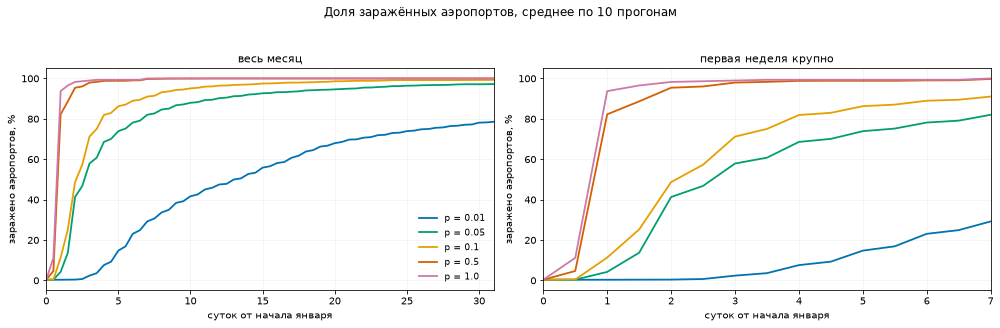

In [16]:
import matplotlib.pyplot as plt

# GitHub не отрисовывает ноутбуки тяжелее 1 МБ, а картинки в base64 — почти весь вес.
plt.rcParams["figure.dpi"] = 72

# Цвета Okabe-Ito: различимы при дальтонизме и в чёрно-белой печати.
PALETTE = ["#0072B2", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

for ax, xmax, title in zip(axes, [31, 7], ["весь месяц", "первая неделя крупно"]):
    for p, color in zip(PROBS, PALETTE):
        ax.plot(days, curves[p] * 100, color=color, linewidth=1.8, label=f"p = {p}")
    ax.set_xlim(0, xmax)
    ax.set_xlabel("суток от начала января")
    ax.set_ylabel("заражено аэропортов, %")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

axes[0].legend(frameon=False, fontsize=9, loc="lower right")
fig.suptitle("Доля заражённых аэропортов, среднее по 10 прогонам", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Кривые для `p = 0.5` и `p = 1` практически слиты: за первые сутки обе накрывают больше 80% сети, дальше обе упираются в один и тот же хвост из нескольких периферийных аэропортов.

Разница между `p = 0.05` и `p = 0.1` в первые двое суток велика, а к концу месяца почти исчезает — оба доходят до 97—99%. По-настоящему выбивается только `p = 0.01`: за месяц она накрывает 78% сети и не насыщается.

### Шаг 4. Что задаёт потолок

Кривые `p = 0.5` и `p = 1` упираются в одну и ту же границу. Смотрим, кто заражается последним и почему.

In [17]:
tail = pd.Series(results[1.0][0]).sort_values().tail(3)

print("последние заражённые при p = 1:")
for node, t in tail.items():
    print(f"  {node}  на {(t - T0) / 86400:.2f}-е сутки")

inbound = events[events.Destination == tail.index[-1]]

print()
print(f"{tail.index[-1]}: входящих рейсов {len(inbound)}, все из {', '.join(sorted(set(inbound.Source)))}")
print(f"первый прилёт на {(inbound.EndTime.min() - T0) / 86400:.2f}-е сутки")

последние заражённые при p = 1:
  ALO  на 3.02-е сутки
  CDC  на 6.69-е сутки
  PLN  на 6.98-е сутки

PLN: входящих рейсов 15, все из DTW
первый прилёт на 6.98-е сутки


Последним при `p = 1` заражается Пеллстон в Мичигане, и раньше 6,98-х суток он не заразится ни при какой вероятности: в него летают только из Детройта, и первый рейс приходит именно тогда.

**Заразность определяет, как быстро сеть накрывает, но не насколько сильно.** Охват насыщается уже при `p ≈ 0.1` — 99,3% за месяц против 100% при `p = 0.5`. Скорость растёт дольше, но и она упирается в расписание: кривые `p = 0.5` и `p = 1` идут почти вместе, потому что инфекция не попадает в аэропорт раньше, чем туда прилетит первый самолёт из уже заражённого города.

## Часть 3. Может ли информация о сети помочь предсказать, кто будет заражён?

### Шаг 1. Взвешенный неориентированный граф

Вес ребра — доля рейсов между парой аэропортов от общего числа рейсов, в обе стороны сразу.

In [18]:
import networkx as nx

# Сортируем пару, чтобы A→Б и Б→A попали в одну группу.
pairs = pd.DataFrame({
    "a": np.minimum(events.Source, events.Destination),
    "b": np.maximum(events.Source, events.Destination),
})

edges = pairs.value_counts().rename("weight").reset_index()
edges["weight"] /= len(events)

G = nx.from_pandas_edgelist(edges, "a", "b", edge_attr="weight")

print(f"узлов             : {G.number_of_nodes()}")
print(f"рёбер             : {G.number_of_edges()}")
print(f"сумма весов       : {edges.weight.sum():.6f}")
print(f"компонент связности: {nx.number_connected_components(G)}")
print()
print(edges.sort_values("weight", ascending=False).head(3).to_string(index=False))

узлов             : 286
рёбер             : 2319
сумма весов       : 1.000000
компонент связности: 1

  a   b   weight
HNL OGG 0.004464
LAS LAX 0.003737
HNL LIH 0.003730


Сумма весов равна единице — все рейсы учтены ровно по разу. Сеть связная, изолированных аэропортов нет, так что теоретически инфекция достижима везде.

Самые тяжёлые рёбра — на Гонолулу — Кахулуи приходится 0,45% всех рейсов месяца.

### Шаг 2. Медианное время заражения

50 прогонов с `p = 0.5` из Allentown.

In [19]:
SIMS = 50

rng = np.random.default_rng(2024)
runs = [simulate(events, START, 0.5, rng) for _ in range(SIMS)]

infected_at = pd.DataFrame(runs).reindex(columns=airports_used)
median_days = (infected_at.median() - T0) / 86400

print(f"прогонов: {SIMS}")
print(f"аэропортов, заражённых не во всех прогонах: {int((infected_at.isna().sum() > 0).sum())}")
print()
print(median_days.describe().round(2).to_string())

прогонов: 50
аэропортов, заражённых не во всех прогонах: 0

count    286.00
mean       0.88
std        0.72
min        0.00
25%        0.60
50%        0.68
75%        0.87
max        6.98


При `p = 0.5` заражаются все 286 аэропортов во всех 50 прогонах, так что медиана считается по полным данным — исключать никого не пришлось.

Половина сети заражается за первые 0,68 суток, а самый поздний аэропорт ждёт почти 7 суток. Распределение сильно скошено вправо.

### Шаг 3. Метрики графа

In [20]:
metrics = pd.DataFrame({
    "median_days": median_days,
    "clustering": pd.Series(nx.clustering(G)),
    "degree": pd.Series(dict(nx.degree(G))),
    "betweenness": pd.Series(nx.betweenness_centrality(G)),
}).loc[airports_used]

metrics.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
median_days,286.0,0.8805,0.7214,0.0,0.6023,0.6844,0.8674,6.9771
clustering,286.0,0.6440,0.4030,0.0,0.2298,0.8261,1.0000,1.0000
degree,286.0,16.2168,26.1790,1.0,2.0000,5.0000,17.0000,166.0000
betweenness,286.0,0.0047,0.0208,0.0,0.0000,0.0000,0.0001,0.2316


`clustering`, `degree` и `betweenness` — три метрики из условия.

### Шаг 4. Scatter-plot'ы

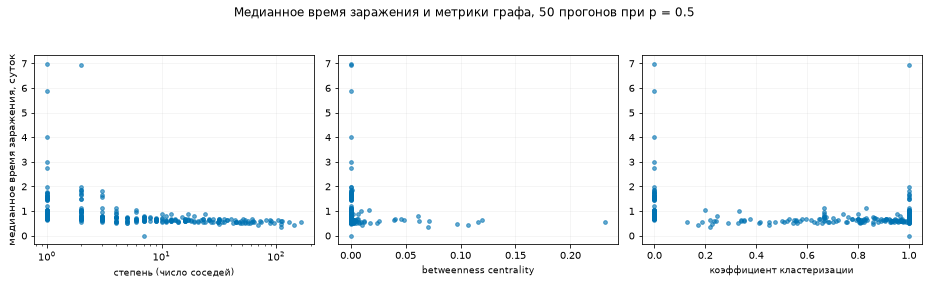

In [21]:
FEATURES = [("degree", "степень (число соседей)"),
            ("betweenness", "betweenness centrality"),
            ("clustering", "коэффициент кластеризации")]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (col, title) in zip(axes, FEATURES):
    ax.scatter(metrics[col], metrics.median_days, s=14, alpha=0.6, color="#0072B2")
    ax.set_xlabel(title, fontsize=9)
    # Логарифм по X: степени растянуты на два порядка.
    if col == "degree":
        ax.set_xscale("log")
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

axes[0].set_ylabel("медианное время заражения, суток")
fig.suptitle("Медианное время заражения и метрики графа, 50 прогонов при p = 0.5", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

На первом графике видна связь: чем больше у аэропорта соседей, тем раньше он заражается, облако лежит вдоль убывающей линии.

У betweenness картина несколько иная: большинство аэропортов имеют нулевой betweenness и растянуты по всей оси Y — метрика их не различает. Но при повышенном betweenness также видно, что заражение происходит раньше

У кластеризации связи не видно: значения жмутся к 0 и 1.

### Шаг 5. Корреляция Спирмана

In [22]:
from scipy.stats import spearmanr

print(f"{'метрика':>34} {'rho':>8} {'p-value':>10}")
for col, title in FEATURES:
    rho, pval = spearmanr(metrics.median_days, metrics[col])
    print(f"{title:>34} {rho:>8.3f} {pval:>10.1e}")

print()
print(f"betweenness == 0: {(metrics.betweenness == 0).sum()} аэропортов")

                           метрика      rho    p-value
           степень (число соседей)   -0.755    6.3e-54
            betweenness centrality   -0.528    6.4e-22
         коэффициент кластеризации   -0.212    3.0e-04

betweenness == 0: 153 аэропортов


Порядок по силе связи: степень, betweenness, кластеризация. Осталось проверить, не повторяют ли метрики друг друга.

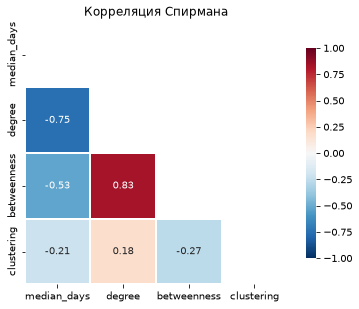

In [23]:
import seaborn as sns

ORDER = ["median_days", "degree", "betweenness", "clustering"]
corr = metrics[ORDER].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5.6, 4.4))

# Прячем диагональ и верх: единицы на диагонали смысла не несут.
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=0.4,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Корреляция Спирмана", fontsize=12)

plt.tight_layout()
plt.show()

Все три связи отрицательные и значимые, но по силе различаются втрое.

**Сильнее всего — степень** (ρ = −0,75). Чтобы заразиться, аэропорту нужен входящий рейс из заражённого города: чем больше у аэропорта соседей, тем больше попыток в единицу времени.

**Betweenness слабее** (ρ = −0,53). Он про транзит — как часто аэропорт лежит на кратчайших путях между другими — а для заражения транзит не нужен. У 153 аэропортов он ровно ноль: это тупики, куда летают из одного-двух хабов, и внутри этой половины сети метрика не различает ничего, хотя времена заражения там от 0,5 до 7 суток. А своё −0,53 betweenness во многом зависит от степени: на карте видно, что между собой они связаны на 0,83, тогда как кластеризация со степенью почти не связана (0,18).

**Кластеризация почти бесполезна** (ρ = −0,21). Она немонотонна по размеру аэропорта: у самых мелких близка к нулю, у средних региональных почти единица, у хабов снова падает. Крайние значения достаются и самым ранним, и самым поздним заражениям.

## Итоговые выводы

### Симуляция

SI-модель написана как один проход по отсортированному по времени вылета датасету. Ключевых тонкостей две: аэропорт вылета должен быть заражён именно к моменту вылета, а время прилёта немонотонно, поэтому уже заражённому аэропорту время нужно уточнять на более раннее, если нашёлся такой рейс.

### Заразность определяет скорость, но не охват

При `p = 0.5` и `p = 1` кривые распространения практически совпадают: за сутки инфекция накрывает более 80% сети, за неделю — практически всю: 99,7% при `p = 0.5` и 100% при `p = 1`. Различаются только медленные режимы: `p = 0.01` за месяц доходит до 78% сети и не насыщается.

Потолок задаёт расписание, а не болезнь.

### Что предсказывает время заражения

| метрика | ρ Спирмана |
|---|---|
| степень | −0,75 |
| betweenness centrality | −0,53 |
| коэффициент кластеризации | −0,21 |

Структура сети предсказывает время заражения хорошо, и лучшая метрика — самая простая. Работает число входящих рейсов, а не положение в топологии.